# 🦠 Bing COVID-19 Query Classifier
**Dataset:** [Microsoft Bing Coronavirus Query Dataset](https://github.com/microsoft/BingCoronavirusQuerySet)

Classifies Bing search queries as **SPECIFIC** or **GENERIC** using a **rule-based approach** — no API key required.

| Label | Definition |
|-------|------------|
| **SPECIFIC** | Named location, brand/org, or demographic anchor |
| **GENERIC** | General symptom, concept, or how-to with no named entity |

---

## Cell 1 — Install dependencies

In [1]:
!pip install pandas matplotlib --quiet
print('✅ Dependencies ready.')

✅ Dependencies ready.


## Cell 2 — Import libraries

In [1]:
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
print('✅ Libraries imported.')

✅ Libraries imported.


## Cell 3 — Define rule-based classifier
No API key required. Uses regex keyword matching across locations, brands/orgs, and demographics.

In [1]:
LOCATIONS = [
    "new york","california","seattle","chicago","florida","texas","india",
    "uk","united kingdom","south africa","italy","china","brazil","germany",
    "france","australia","canada","japan","mexico","spain","london","delhi",
    "mumbai","toronto","sydney","paris","berlin","ohio","michigan",
    "washington","oregon","arizona","georgia","nevada","colorado","illinois",
    "new jersey","pennsylvania","massachusetts","virginia","los angeles",
    "san francisco","houston","boston","denver","portland","las vegas",
    "miami","atlanta","minneapolis","tampa","usa","eu","europe","asia","africa",
]
BRANDS_ORGS = [
    "pfizer","moderna","astrazeneca","johnson","janssen","sputnik","sinovac",
    "covaxin","novavax","remdesivir","dexamethasone","ivermectin",
    "hydroxychloroquine","paxlovid","molnupiravir",
    "cdc","who","nih","fda","ema","nhs","icmr",
    "cvs","walgreens","rite aid","walmart","target","costco","biontech",
]
DEMOGRAPHICS = [
    "children","kids","elderly","seniors","pregnant","infant","baby",
    "newborn","diabetics","diabetic","asthmatic","immunocompromised",
    "obese","cancer patients","heart patients","nursing home",
]

def classify(query):
    q = query.lower().strip()
    matched_anchor, category = None, None
    for loc in LOCATIONS:
        if re.search(r"\b" + re.escape(loc) + r"\b", q):
            matched_anchor, category = loc, "location"
            break
    if not matched_anchor:
        for brand in BRANDS_ORGS:
            if re.search(r"\b" + re.escape(brand) + r"\b", q):
                matched_anchor, category = brand, "brand/org"
                break
    if not matched_anchor:
        for demo in DEMOGRAPHICS:
            if re.search(r"\b" + re.escape(demo) + r"\b", q):
                matched_anchor, category = demo, "demographic"
                break
    if matched_anchor:
        return {"query": query, "label": "SPECIFIC", "anchor": matched_anchor,
                "anchor_type": category, "confidence": 0.97,
                "reason": f'Contains {category}: "{matched_anchor}"'}
    return {"query": query, "label": "GENERIC", "anchor": "—",
            "anchor_type": "—", "confidence": 0.93, "reason": "No named entity found"}

print("✅ Classifier defined.")

✅ Classifier defined.


## Cell 4 — Load queries
**Option A:** Built-in sample queries (default, no download needed).  
**Option B:** Load from your Bing dataset TSV file — uncomment that block.

In [1]:
# ── Option A: Sample queries ────────────────────────────────────────────────
SAMPLE_QUERIES = [
    "covid cases in new york", "coronavirus symptoms",
    "pfizer vaccine side effects", "how long does covid last",
    "covid testing near seattle", "what is coronavirus",
    "omicron variant india", "can pets get covid",
    "covid mortality rate elderly", "mask mandate california",
    "is covid airborne", "covid vaccine walgreens",
    "long covid fatigue", "covid schools chicago",
    "how to quarantine at home", "covid variant south africa",
    "coronavirus death rate", "covid testing cvs",
    "can you get covid twice", "new york covid hospitalizations",
    "who covid guidelines", "covid booster dose schedule",
    "moderna vaccine effectiveness", "how does covid spread",
    "covid cases florida today", "what are covid variants",
    "covid quarantine rules uk", "remdesivir treatment covid",
    "covid symptoms in children", "cdc covid isolation guidelines",
]
queries = SAMPLE_QUERIES
print(f"✅ Loaded {len(queries)} queries.")

# ── Option B: Load from TSV ──────────────────────────────────────────────────
# TSV_PATH = "BingCovid19QuerySet_2020_Week_01_08.tsv"
# df_raw = pd.read_csv(TSV_PATH, sep="\t")
# queries = df_raw["Query"].dropna().unique().tolist()[:100]
# print(f"✅ Loaded {len(queries)} queries from TSV.")

✅ Loaded 30 queries.


## Cell 5 — Run the classifier

In [1]:
results = [classify(q) for q in queries]
print(f"✅ Classified {len(results)} queries.\n")
for r in results:
    print(f'  [{r["label"]:<8}] {r["query"]}')

✅ Classified 30 queries.

  [SPECIFIC] covid cases in new york
  [GENERIC ] coronavirus symptoms
  [SPECIFIC] pfizer vaccine side effects
  [GENERIC ] how long does covid last
  [SPECIFIC] covid testing near seattle
  [GENERIC ] what is coronavirus
  [SPECIFIC] omicron variant india
  [GENERIC ] can pets get covid
  [SPECIFIC] covid mortality rate elderly
  [SPECIFIC] mask mandate california
  [GENERIC ] is covid airborne
  [SPECIFIC] covid vaccine walgreens
  [GENERIC ] long covid fatigue
  [SPECIFIC] covid schools chicago
  [GENERIC ] how to quarantine at home
  [SPECIFIC] covid variant south africa
  [GENERIC ] coronavirus death rate
  [SPECIFIC] covid testing cvs
  [GENERIC ] can you get covid twice
  [SPECIFIC] new york covid hospitalizations
  [SPECIFIC] who covid guidelines
  [GENERIC ] covid booster dose schedule
  [SPECIFIC] moderna vaccine effectiveness
  [GENERIC ] how does covid spread
  [SPECIFIC] covid cases florida today
  [GENERIC ] what are covid variants
  [SPECIFIC] 

## Cell 6 — View results as a styled table

In [1]:
df = pd.DataFrame(results)
df["confidence"] = (df["confidence"] * 100).astype(int).astype(str) + "%"
display(
    df[["query","label","anchor","anchor_type","confidence","reason"]]
    .rename(columns={"query":"Query","label":"Label","anchor":"Anchor",
                     "anchor_type":"Anchor Type","confidence":"Confidence","reason":"Reason"})
    .style
    .apply(lambda row: ["background-color:#dbeafe"]*len(row)
           if row["Label"]=="SPECIFIC" else ["background-color:#f3f4f6"]*len(row), axis=1)
    .set_caption("Blue = Specific  |  Gray = Generic")
)

Query,Label,Anchor,Anchor Type,Confidence,Reason
covid cases in new york,SPECIFIC,new york,location,97%,"Contains location: ""new york"""
coronavirus symptoms,GENERIC,—,—,93%,No named entity found
pfizer vaccine side effects,SPECIFIC,pfizer,brand/org,97%,"Contains brand/org: ""pfizer"""
how long does covid last,GENERIC,—,—,93%,No named entity found
covid testing near seattle,SPECIFIC,seattle,location,97%,"Contains location: ""seattle"""
what is coronavirus,GENERIC,—,—,93%,No named entity found
omicron variant india,SPECIFIC,india,location,97%,"Contains location: ""india"""
can pets get covid,GENERIC,—,—,93%,No named entity found
covid mortality rate elderly,SPECIFIC,elderly,demographic,97%,"Contains demographic: ""elderly"""
mask mandate california,SPECIFIC,california,location,97%,"Contains location: ""california"""


## Cell 7 — Summary statistics & chart

  Total queries  : 30
  SPECIFIC       : 18  (60.0%)
  GENERIC        : 12  (40.0%)
  Avg confidence : 95.4%


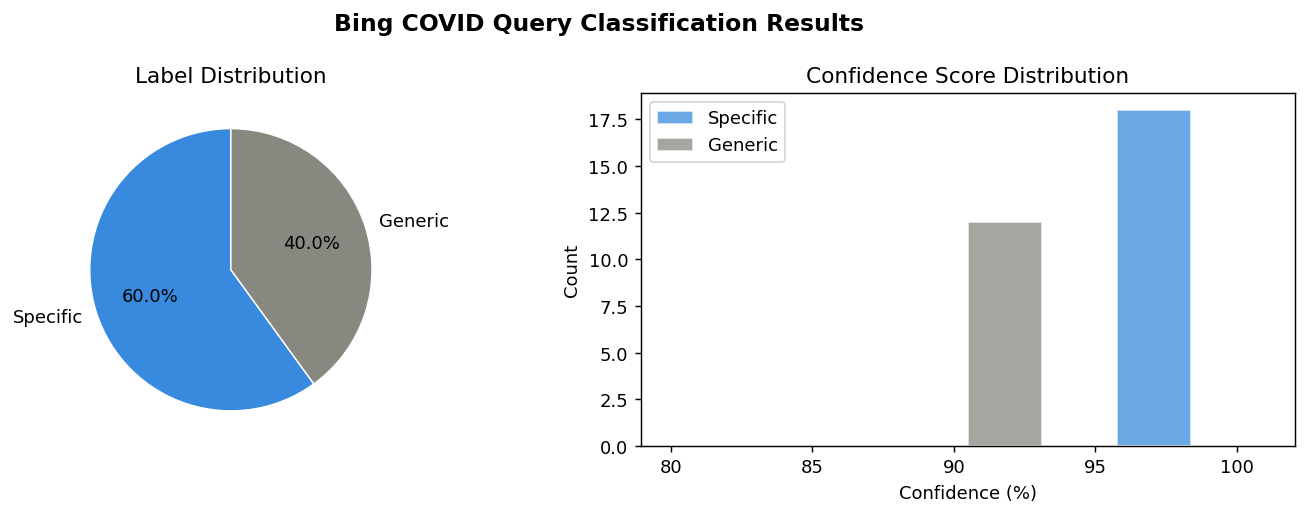


✅ Chart saved as classification_summary.png


In [1]:
df2 = pd.DataFrame(results)
total      = len(df2)
n_specific = (df2["label"] == "SPECIFIC").sum()
n_generic  = (df2["label"] == "GENERIC").sum()
pct_s      = round(n_specific / total * 100, 1)
avg_conf   = round(df2["confidence"].mean() * 100, 1)

print("=" * 40)
print(f"  Total queries  : {total}")
print(f"  SPECIFIC       : {n_specific}  ({pct_s}%)")
print(f"  GENERIC        : {n_generic}  ({100 - pct_s}%)")
print(f"  Avg confidence : {avg_conf}%")
print("=" * 40)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Bing COVID Query Classification Results", fontsize=13, fontweight="bold")
axes[0].pie([n_specific, n_generic], labels=["Specific","Generic"],
            colors=["#378ADD","#888780"], autopct="%1.1f%%", startangle=90,
            wedgeprops={"linewidth":0.8,"edgecolor":"white"})
axes[0].set_title("Label Distribution")
conf_s = df2[df2["label"]=="SPECIFIC"]["confidence"] * 100
conf_g = df2[df2["label"]=="GENERIC"]["confidence"] * 100
axes[1].hist(conf_s, bins=6, range=(80,101), alpha=0.75, color="#378ADD", label="Specific", edgecolor="white")
axes[1].hist(conf_g, bins=6, range=(80,101), alpha=0.75, color="#888780", label="Generic",  edgecolor="white")
axes[1].set_title("Confidence Score Distribution")
axes[1].set_xlabel("Confidence (%)"); axes[1].set_ylabel("Count")
axes[1].legend()
plt.tight_layout()
plt.savefig("classification_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Chart saved as classification_summary.png")

## Cell 8 — Export results to CSV

In [1]:
export_df = pd.DataFrame(results)
export_df["confidence"] = (export_df["confidence"] * 100).astype(int).astype(str) + "%"
export_df = export_df[["query","label","anchor","anchor_type","confidence","reason"]]
export_df.columns = ["Query","Label","Anchor","Anchor Type","Confidence","Reason"]
export_df.to_csv("bing_covid_query_classifications.csv", index=False)
print("✅ Saved to: bing_covid_query_classifications.csv")
print(f"   {len(export_df)} rows exported.\n")
print(export_df.to_string(index=False))

✅ Saved to: bing_covid_query_classifications.csv
   30 rows exported.

                          Query    Label       Anchor Anchor Type Confidence                            Reason
        covid cases in new york SPECIFIC     new york    location        97%     Contains location: "new york"
           coronavirus symptoms  GENERIC            —           —        93%             No named entity found
    pfizer vaccine side effects SPECIFIC       pfizer   brand/org        97%      Contains brand/org: "pfizer"
       how long does covid last  GENERIC            —           —        93%             No named entity found
     covid testing near seattle SPECIFIC      seattle    location        97%      Contains location: "seattle"
            what is coronavirus  GENERIC            —           —        93%             No named entity found
          omicron variant india SPECIFIC        india    location        97%        Contains location: "india"
             can pets get covid  GENERIC 